In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
import numpy as np
import matplotlib.pyplot as plt
import os

IMG_SIZE = 512

BATCH_SIZE = 8

LATENT_DIM = 100

EPOCHS = 300

CAT_FOLDER = "cats"

GENERATED_FOLDER = "gan_saved"

os.makedirs(
    GENERATED_FOLDER,
    exist_ok=True
)

In [3]:
# data load

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    CAT_FOLDER,
    label_mode=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

dataset = dataset.map(
    lambda x: (x / 127.5) - 1
)

Found 45 files.


In [4]:
# Generator

from tensorflow.keras import layers

def build_generator():

    model = tf.keras.Sequential()

    model.add(
        layers.Dense(
            8*8*256,
            use_bias=False,
            input_shape=(LATENT_DIM,)
        )
    )

    model.add(
        layers.BatchNormalization()
    )

    model.add(
        layers.LeakyReLU()
    )

    model.add(
        layers.Reshape((8,8,256))
    )

    model.add(
        layers.Conv2DTranspose(
            128,
            4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )

    model.add(
        layers.BatchNormalization()
    )

    model.add(
        layers.LeakyReLU()
    )

    model.add(
        layers.Conv2DTranspose(
            64,
            4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )

    model.add(
        layers.BatchNormalization()
    )

    model.add(
        layers.LeakyReLU()
    )

    model.add(
        layers.Conv2DTranspose(
            3,
            4,
            strides=2,
            padding="same",
            activation="tanh"
        )
    )

    return model

In [5]:
# Discriminator

def build_discriminator():

    model = tf.keras.Sequential()

    model.add(
        layers.Conv2D(
            64,
            4,
            strides=2,
            padding="same",
            input_shape=(64,64,3)
        )
    )

    model.add(
        layers.LeakyReLU()
    )

    model.add(
        layers.Dropout(0.3)
    )

    model.add(
        layers.Conv2D(
            128,
            4,
            strides=2,
            padding="same"
        )
    )

    model.add(
        layers.LeakyReLU()
    )

    model.add(
        layers.Dropout(0.3)
    )

    model.add(
        layers.Flatten()
    )

    model.add(
        layers.Dense(1)
    )

    return model

In [6]:
# 모델 생성 
generator = build_generator()

discriminator = build_discriminator()

a:\conding_program\envs\car_cls\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
a:\conding_program\envs\car_cls\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

def discriminator_loss(
        real_output,
        fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

In [8]:
#  optimizer

generator_optimizer = tf.keras.optimizers.Adam(
    0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    0.0002,
    beta_1=0.5
)

In [9]:
# train

@tf.function
def train_step(images):

    noise = tf.random.normal(
        [tf.shape(images)[0], LATENT_DIM]
    )

    with tf.GradientTape() as gen_tape,\
         tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [10]:
# epoch 학습

for epoch in range(EPOCHS):

    for image_batch in dataset:

        g_loss, d_loss = train_step(
            image_batch
        )

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch}",
            f"G={g_loss:.4f}",
            f"D={d_loss:.4f}"
        )

Epoch 0 G=0.7307 D=0.8608
Epoch 10 G=3.6519 D=0.0352
Epoch 20 G=3.4014 D=0.1026
Epoch 30 G=2.6115 D=0.1153
Epoch 40 G=4.0175 D=0.0811
Epoch 50 G=3.3675 D=0.0914
Epoch 60 G=4.1861 D=0.1094
Epoch 70 G=4.3697 D=0.0438
Epoch 80 G=3.0917 D=0.1043
Epoch 90 G=3.0906 D=0.0926
Epoch 100 G=2.3611 D=0.2013
Epoch 110 G=2.8641 D=0.1365
Epoch 120 G=2.1592 D=0.1621
Epoch 130 G=1.0890 D=0.6416
Epoch 140 G=2.5287 D=0.1892
Epoch 150 G=3.3296 D=0.2889
Epoch 160 G=2.7666 D=0.1917
Epoch 170 G=1.8314 D=0.2573
Epoch 180 G=2.0449 D=0.3004
Epoch 190 G=2.3979 D=0.2305
Epoch 200 G=1.4882 D=0.3864
Epoch 210 G=2.0554 D=0.2564
Epoch 220 G=1.7835 D=0.2711
Epoch 230 G=2.6450 D=0.3467
Epoch 240 G=1.3978 D=0.3837
Epoch 250 G=3.2479 D=0.8305
Epoch 260 G=1.3279 D=0.4431
Epoch 270 G=3.3666 D=0.9929
Epoch 280 G=0.5517 D=0.9843
Epoch 290 G=0.6898 D=0.8286


In [11]:
# 생성

noise = tf.random.normal(
    [16, LATENT_DIM]
)

generated_images = generator(
    noise,
    training=False
)

generated_images = (
    generated_images + 1
) / 2

ValueError: num must be an integer with 1 <= num <= 16, not 17

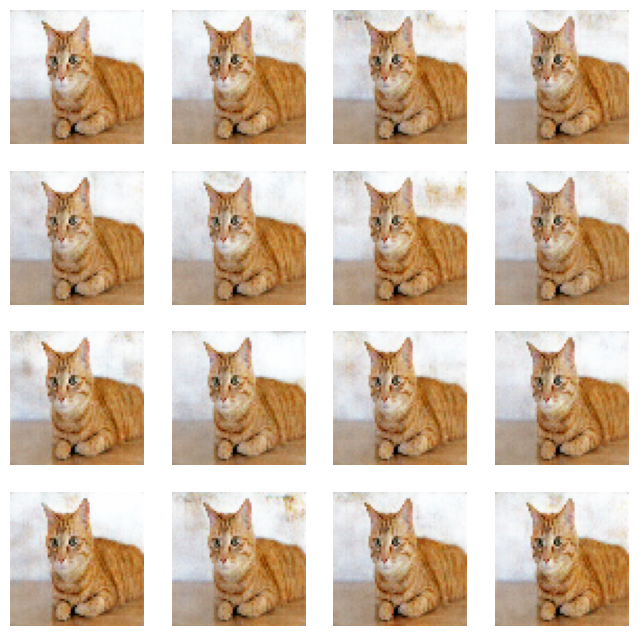

In [12]:
# 생성 결과 출력

plt.figure(figsize=(8,8))

for i in range(20):

    plt.subplot(4,4,i+1)

    plt.imshow(
        generated_images[i]
    )

    plt.axis("off")

plt.show()

In [ ]:
# 저장

for i in range(16):

    img = generated_images[i].numpy()

    plt.imsave(
        f"generated/cat_{i}.png",
        img
    )